In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.impute import SimpleImputer

In [2]:
DATA_DIR = "../../data/raw/final_dataset.csv"

# adjust to not use much memory
CHUNK_SIZE = 20_000
MAX_LABEL = 10_000

In [ ]:
def get_usage():
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / (1024 ** 2) # MB
    cpu_time = process.cpu_times().user + process.cpu_times().system
    return mem, cpu_time

start_mem, start_cpu = get_usage()
start_wall = time.time()

In [3]:
counts = {}
parts = []

for chunk in pd.read_csv(DATA_DIR, chunksize=CHUNK_SIZE):
    for label, group in chunk.groupby("Label"):
        n = counts.get(label, 0)
        if n >= MAX_LABEL:
            continue

        group_shuffled = group.sample(frac=1, random_state=1)
        take = group_shuffled.iloc[: MAX_LABEL - n]
        parts.append(take)
        counts[label] = n + len(take)

    if len(counts) == 2 and all(c >= MAX_LABEL for c in counts.values()):
        break

df = pd.concat(parts, ignore_index=True)
df = df.sample(frac=1, random_state=1).reset_index(drop=True)
print(df["Label"].value_counts())

Label
Benign    10000
ddos      10000
Name: count, dtype: int64


In [4]:
df_features = df.copy()

columns_to_drop = [
    "Label",
    "Unnamed: 0",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp",
    "Src Port",
    "Dst Port",
]
df_features = df_features.drop(columns=columns_to_drop, errors="ignore")

# One-hot encode Protocol
if "Protocol" in df_features.columns:
    df_features = pd.get_dummies(df_features, columns=["Protocol"], prefix="Protocol")

feature_names = df_features.columns
X = df_features.values
y = df["Label"].values

# numeric labels: 1 for ddos, 0 for Benign
y_numeric = np.where(y == "ddos", 1, 0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label vector shape: {y_numeric.shape}")
print(f"Number of features: {X.shape[1]}")


Feature matrix shape: (20000, 79)
Label vector shape: (20000,)
Number of features: 79


In [5]:
X = X.astype(np.float64)
X = np.where(np.isinf(X), np.nan, X)

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_numeric,
    test_size=0.2,
    random_state=1,
    stratify=y_numeric,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,  # 0.25 of 0.8 = 0.2
    random_state=1,
    stratify=y_temp,
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (12000, 79) Val: (4000, 79) Test: (4000, 79)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [8]:
C_values = np.logspace(-4, 4, 10)   # fewer points to start
settings = [
    ("none", None),
    ("balanced", "balanced"),
]

val_results = []  # (C, class_weight_name, train_acc, val_acc)

for cw_name, cw in settings:
    train_accs = []
    val_accs = []

    for C in C_values:
        lr = LogisticRegression(
            C=C,
            penalty="l2",
            solver="saga",
            class_weight=cw,
            max_iter=3000,
            tol=1e-3,
            n_jobs=-1,
            random_state=1,
        )

        lr.fit(X_train_scaled, y_train)

        y_train_pred = lr.predict(X_train_scaled)
        y_val_pred = lr.predict(X_val_scaled)

        tr_acc = accuracy_score(y_train, y_train_pred)
        va_acc = accuracy_score(y_val, y_val_pred)

        train_accs.append(tr_acc)
        val_accs.append(va_acc)
        
        tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

        fpr = fp / (fp + tn)
        recall = tp / (tp + fn)
        
        val_results.append((C, cw_name, tr_acc, va_acc, fpr, recall))

        print(f"done: cw={cw_name}, C={C:.4g}, val_acc={va_acc:.4f}")  # progress

    best_idx = int(np.argmax(val_accs))
    print(f"[{cw_name}] best C={C_values[best_idx]:.4g} | val_acc={val_accs[best_idx]:.4f}")

done: cw=none, C=0.0001, val_acc=0.9788
done: cw=none, C=0.0007743, val_acc=0.9815
done: cw=none, C=0.005995, val_acc=0.9825
done: cw=none, C=0.04642, val_acc=0.9855
done: cw=none, C=0.3594, val_acc=0.9850
done: cw=none, C=2.783, val_acc=0.9852
done: cw=none, C=21.54, val_acc=0.9852
done: cw=none, C=166.8, val_acc=0.9852
done: cw=none, C=1292, val_acc=0.9852
done: cw=none, C=1e+04, val_acc=0.9852
[none] best C=0.04642 | val_acc=0.9855
done: cw=balanced, C=0.0001, val_acc=0.9788
done: cw=balanced, C=0.0007743, val_acc=0.9815
done: cw=balanced, C=0.005995, val_acc=0.9825
done: cw=balanced, C=0.04642, val_acc=0.9855
done: cw=balanced, C=0.3594, val_acc=0.9850
done: cw=balanced, C=2.783, val_acc=0.9852
done: cw=balanced, C=21.54, val_acc=0.9852
done: cw=balanced, C=166.8, val_acc=0.9852
done: cw=balanced, C=1292, val_acc=0.9852
done: cw=balanced, C=1e+04, val_acc=0.9852
[balanced] best C=0.04642 | val_acc=0.9855


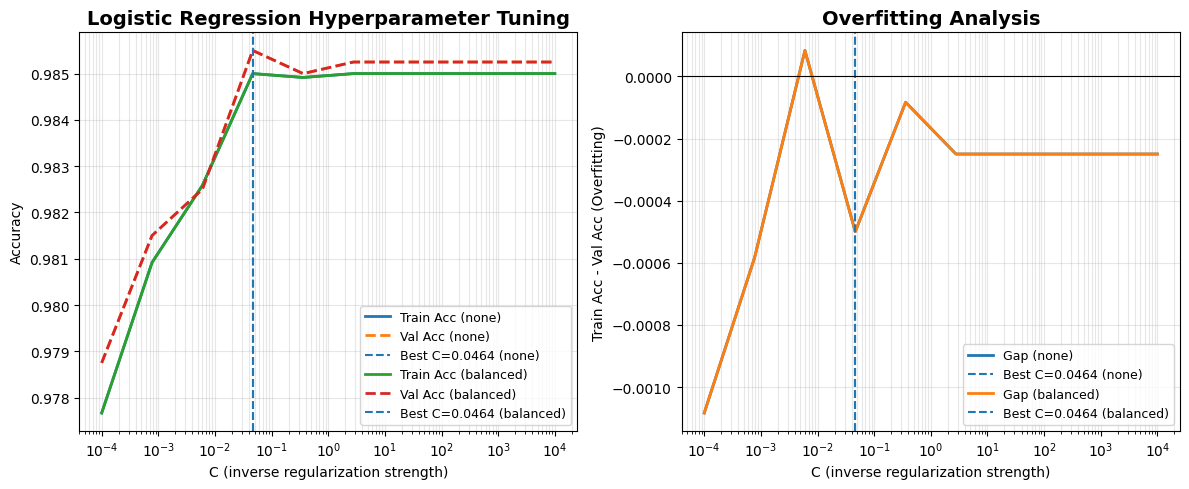

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ---- Visualising: LR Hyperparameter tuning (Accuracy vs C) + Overfitting gap ----
# val_results format expected: (C, cw_name, tr_acc, va_acc, fpr, recall)

plt.figure(figsize=(12, 5))

# Panel 1: Accuracy vs C
plt.subplot(1, 2, 1)

best_per_cw = {}  # cw_name -> (best_C, best_val_acc)

for cw_name, _ in settings:
    subset = [r for r in val_results if r[1] == cw_name]

    Cs = np.array([r[0] for r in subset])
    tr = np.array([r[2] for r in subset])
    va = np.array([r[3] for r in subset])

    order = np.argsort(Cs)
    Cs, tr, va = Cs[order], tr[order], va[order]

    plt.plot(Cs, tr, linewidth=2, label=f"Train Acc ({cw_name})")
    plt.plot(Cs, va, linewidth=2, linestyle="--", label=f"Val Acc ({cw_name})")

    best_idx = int(np.argmax(va))
    best_C = Cs[best_idx]
    best_val = va[best_idx]
    best_per_cw[cw_name] = (best_C, best_val)

    plt.axvline(best_C, linestyle="--", linewidth=1.5, label=f"Best C={best_C:.3g} ({cw_name})")

plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Accuracy")
plt.title("Logistic Regression Hyperparameter Tuning", fontsize=14, fontweight="bold")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=9)

# Panel 2: Overfitting gap (Train - Val) vs C
plt.subplot(1, 2, 2)

for cw_name, _ in settings:
    subset = [r for r in val_results if r[1] == cw_name]

    Cs = np.array([r[0] for r in subset])
    tr = np.array([r[2] for r in subset])
    va = np.array([r[3] for r in subset])

    order = np.argsort(Cs)
    Cs, tr, va = Cs[order], tr[order], va[order]

    gap = tr - va
    plt.plot(Cs, gap, linewidth=2, label=f"Gap ({cw_name})")

    # draw the best C line again
    best_C, _ = best_per_cw[cw_name]
    plt.axvline(best_C, linestyle="--", linewidth=1.5, label=f"Best C={best_C:.3g} ({cw_name})")

plt.axhline(y=0, color="black", linewidth=0.8)
plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Train Acc - Val Acc (Overfitting)")
plt.title("Overfitting Analysis", fontsize=14, fontweight="bold")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=9)

plt.tight_layout()

# Save (make sure folder exists)
os.makedirs("../../plots", exist_ok=True)
plt.savefig("../../plots/lr_hyperparameter_tuning_overfitting.png", dpi=300, bbox_inches="tight")

plt.show()


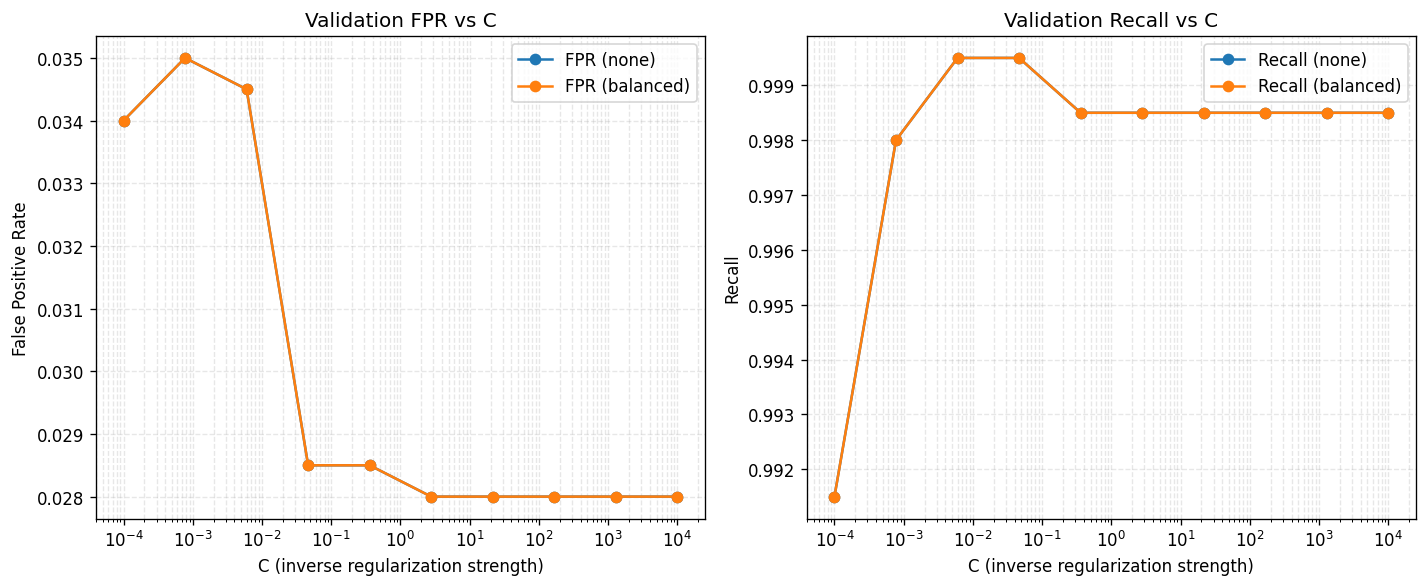

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

for cw_name, _ in settings:
    subset = [r for r in val_results if r[1] == cw_name]

    Cs = np.array([r[0] for r in subset])
    fprs = np.array([r[4] for r in subset])
    recalls = np.array([r[5] for r in subset])

    order = np.argsort(Cs)
    Cs, fprs, recalls = Cs[order], fprs[order], recalls[order]

    axes[0].plot(Cs, fprs, marker="o", label=f"FPR ({cw_name})")
    axes[1].plot(Cs, recalls, marker="o", label=f"Recall ({cw_name})")

axes[0].set_xscale("log")
axes[0].set_xlabel("C (inverse regularization strength)")
axes[0].set_ylabel("False Positive Rate")
axes[0].set_title("Validation FPR vs C")
axes[0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_xlabel("C (inverse regularization strength)")
axes[1].set_ylabel("Recall")
axes[1].set_title("Validation Recall vs C")
axes[1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("../../plots/lr_fpr_recall_vs_C.png", dpi=300, bbox_inches="tight")
plt.show()

  class_weight  best_acc_C  best_val_acc  best_acc_FPR  best_acc_recall  \
0         none    0.046416        0.9855        0.0285           0.9995   
1     balanced    0.046416        0.9855        0.0285           0.9995   

   best_fpr_C  lowest_FPR  fpr_recall  fpr_val_acc  
0    2.782559       0.028      0.9985      0.98525  
1    2.782559       0.028      0.9985      0.98525  


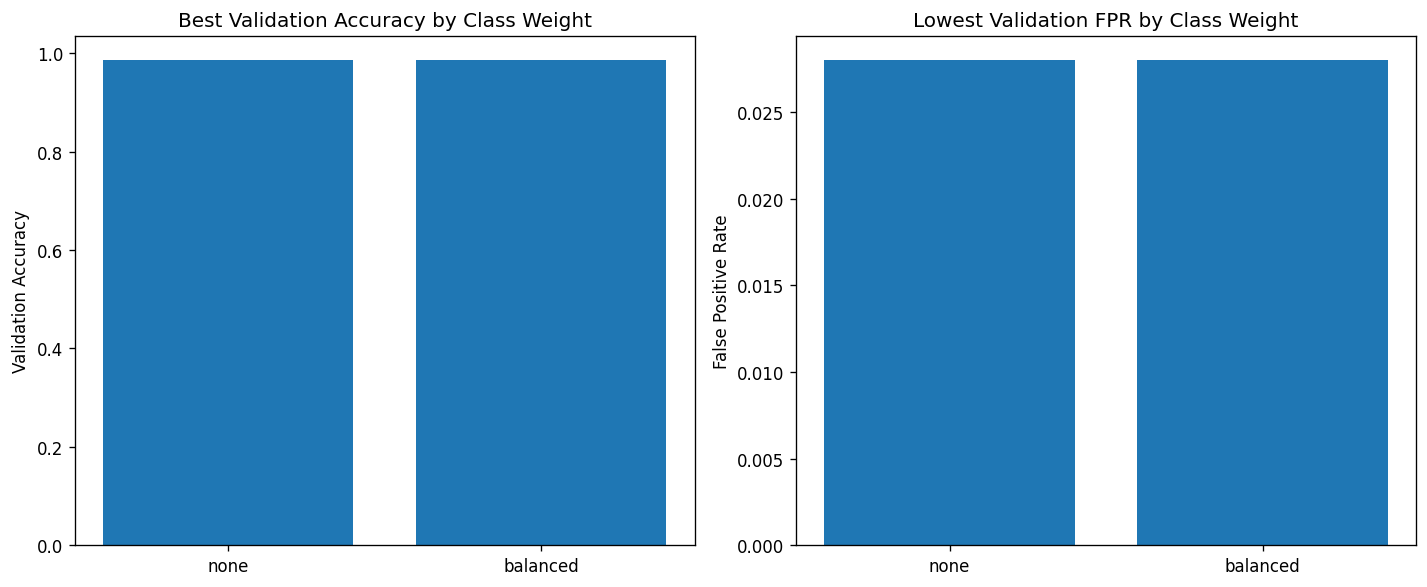

In [11]:
weighting_summary = []

for cw_name, _ in settings:
    subset = [r for r in val_results if r[1] == cw_name]

    best_by_acc = max(subset, key=lambda t: t[3])
    best_by_fpr = min(subset, key=lambda t: t[4])

    weighting_summary.append({
        "class_weight": cw_name,
        "best_acc_C": best_by_acc[0],
        "best_val_acc": best_by_acc[3],
        "best_acc_FPR": best_by_acc[4],
        "best_acc_recall": best_by_acc[5],
        "best_fpr_C": best_by_fpr[0],
        "lowest_FPR": best_by_fpr[4],
        "fpr_recall": best_by_fpr[5],
        "fpr_val_acc": best_by_fpr[3],
    })

weighting_df = pd.DataFrame(weighting_summary)
print(weighting_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

axes[0].bar(weighting_df["class_weight"], weighting_df["best_val_acc"])
axes[0].set_title("Best Validation Accuracy by Class Weight")
axes[0].set_ylabel("Validation Accuracy")

axes[1].bar(weighting_df["class_weight"], weighting_df["lowest_FPR"])
axes[1].set_title("Lowest Validation FPR by Class Weight")
axes[1].set_ylabel("False Positive Rate")

plt.tight_layout()
plt.savefig("../../plots/lr_class_weighting_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
best = max(val_results, key=lambda t: t[3])  # maximize val_acc
best_C, best_cw_name, best_train_acc, best_val_acc, best_fpr, best_recall = best
best_cw = "balanced" if best_cw_name == "balanced" else None

final_lr = LogisticRegression(
    C=best_C,
    penalty="l2",
    solver="saga",
    class_weight=best_cw,
    max_iter=3000,
    tol=1e-3,
    n_jobs=-1,
    random_state=1,
)
final_lr.fit(X_train_scaled, y_train)

print("Best setting:", best)

Best setting: (np.float64(0.046415888336127774), 'none', 0.985, 0.9855, np.float64(0.0285), np.float64(0.9995))


threshold=0.1 | FPR=0.0415 | Recall=1.0000 | Precision=0.9602
threshold=0.2 | FPR=0.0390 | Recall=0.9995 | Precision=0.9624
threshold=0.3 | FPR=0.0385 | Recall=0.9995 | Precision=0.9629
threshold=0.4 | FPR=0.0365 | Recall=0.9995 | Precision=0.9648
threshold=0.5 | FPR=0.0285 | Recall=0.9995 | Precision=0.9723
threshold=0.6 | FPR=0.0265 | Recall=0.9965 | Precision=0.9741
threshold=0.7 | FPR=0.0245 | Recall=0.9955 | Precision=0.9760
threshold=0.8 | FPR=0.0160 | Recall=0.9755 | Precision=0.9839
threshold=0.9 | FPR=0.0100 | Recall=0.9540 | Precision=0.9896


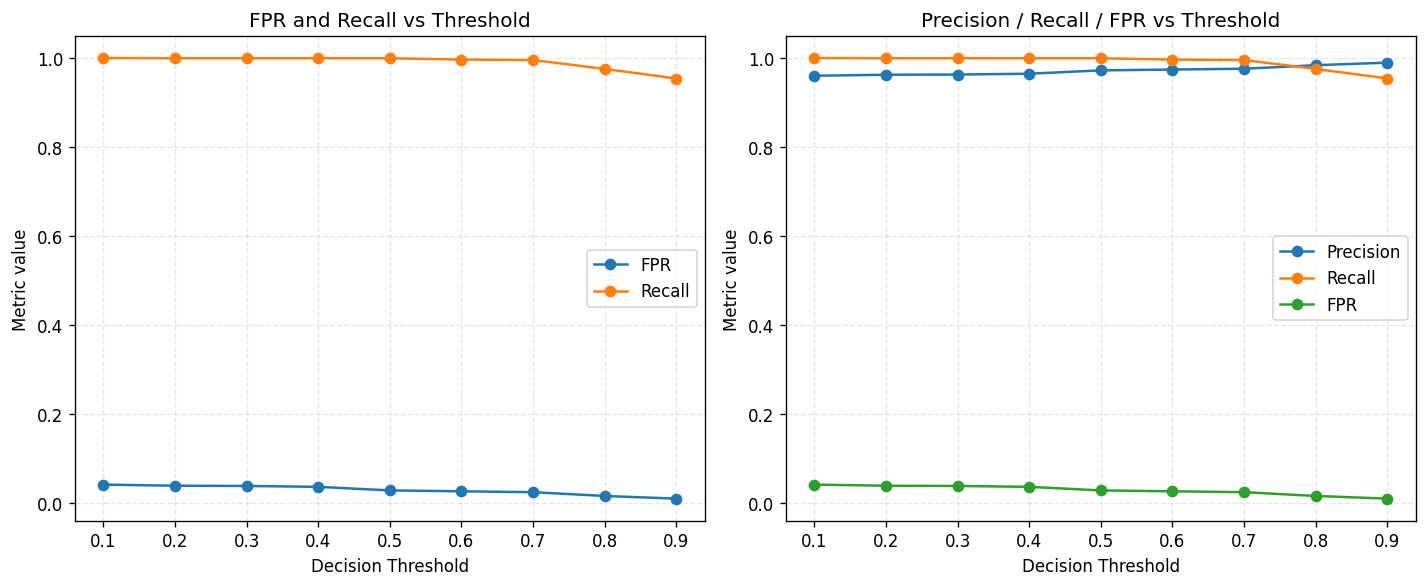

In [13]:
y_val_proba = final_lr.predict_proba(X_val_scaled)[:, 1]
thresholds_to_try = np.arange(0.1, 1.0, 0.1)

threshold_results = []

for thr in thresholds_to_try:
    y_val_thr_pred = (y_val_proba >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_val_thr_pred).ravel()

    fpr = fp / (fp + tn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    threshold_results.append((thr, fpr, recall, precision))

    print(
        f"threshold={thr:.1f} | "
        f"FPR={fpr:.4f} | Recall={recall:.4f} | Precision={precision:.4f}"
    )

thr_vals = np.array([r[0] for r in threshold_results])
fpr_vals = np.array([r[1] for r in threshold_results])
recall_vals = np.array([r[2] for r in threshold_results])
precision_vals = np.array([r[3] for r in threshold_results])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

axes[0].plot(thr_vals, fpr_vals, marker="o", label="FPR")
axes[0].plot(thr_vals, recall_vals, marker="o", label="Recall")
axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel("Metric value")
axes[0].set_title("FPR and Recall vs Threshold")
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].legend()

axes[1].plot(thr_vals, precision_vals, marker="o", label="Precision")
axes[1].plot(thr_vals, recall_vals, marker="o", label="Recall")
axes[1].plot(thr_vals, fpr_vals, marker="o", label="FPR")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Metric value")
axes[1].set_title("Precision / Recall / FPR vs Threshold")
axes[1].grid(True, linestyle="--", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("../../plots/lr_threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

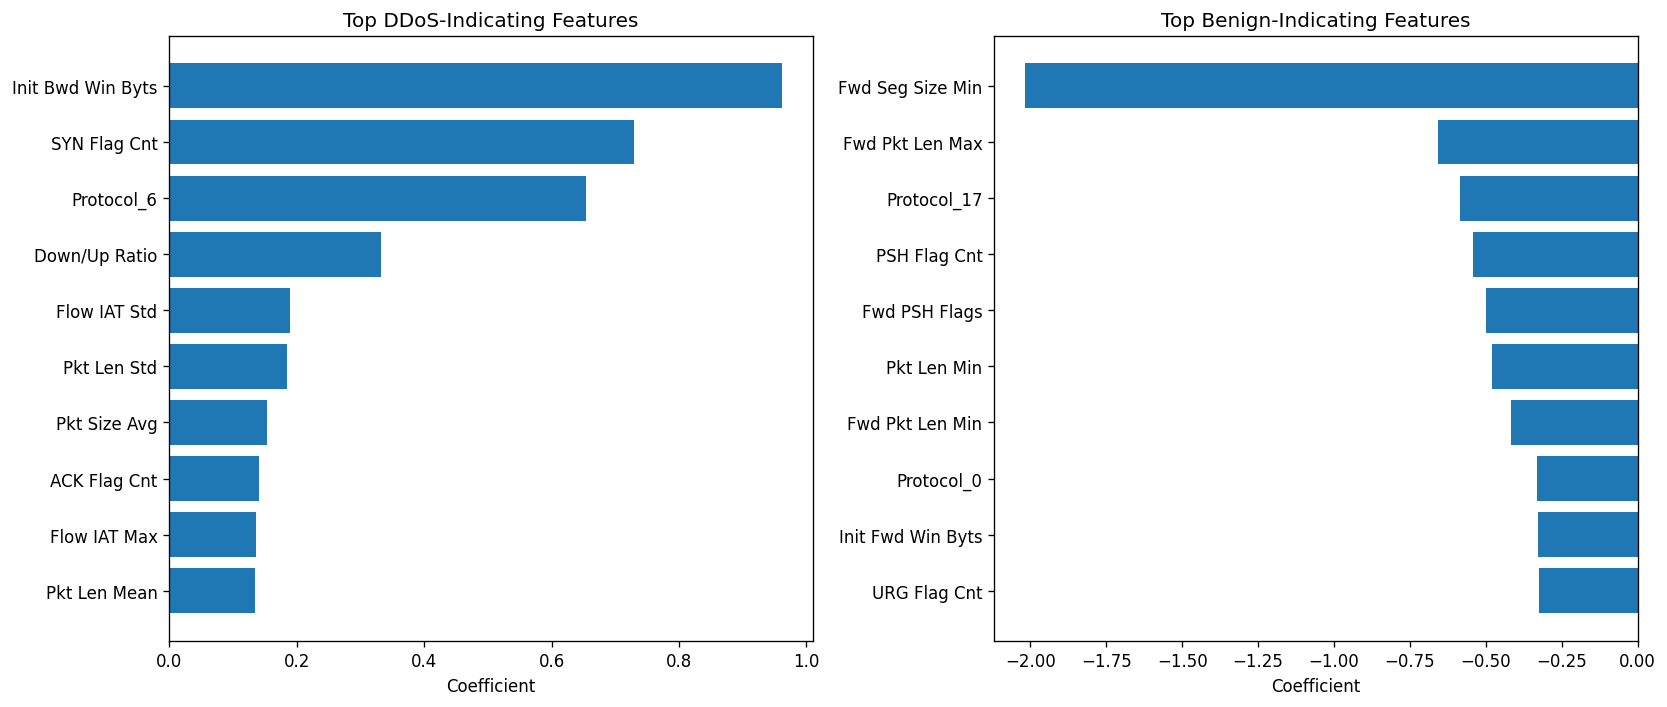

Top DDoS-indicating features:
              feature  coefficient
65  Init Bwd Win Byts     0.961717
43       SYN Flag Cnt     0.728596
77         Protocol_6     0.654806
50      Down/Up Ratio     0.332582
16       Flow IAT Std     0.189328
40        Pkt Len Std     0.184617
51       Pkt Size Avg     0.154275
46       ACK Flag Cnt     0.140661
17       Flow IAT Max     0.135559
39       Pkt Len Mean     0.133940

Top Benign-indicating features:
              feature  coefficient
67   Fwd Seg Size Min    -2.018411
5     Fwd Pkt Len Max    -0.658282
78        Protocol_17    -0.585899
45       PSH Flag Cnt    -0.542615
29      Fwd PSH Flags    -0.498317
37        Pkt Len Min    -0.478304
6     Fwd Pkt Len Min    -0.417933
76         Protocol_0    -0.332792
64  Init Fwd Win Byts    -0.327063
47       URG Flag Cnt    -0.323473


In [14]:
coef = final_lr.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_ddos = coef_df.sort_values("coefficient", ascending=False).head(10)
top_benign = coef_df.sort_values("coefficient", ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

axes[0].barh(top_ddos["feature"], top_ddos["coefficient"])
axes[0].invert_yaxis()
axes[0].set_title("Top DDoS-Indicating Features")
axes[0].set_xlabel("Coefficient")

axes[1].barh(top_benign["feature"], top_benign["coefficient"])
axes[1].invert_yaxis()
axes[1].set_title("Top Benign-Indicating Features")
axes[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.savefig("../../plots/lr_feature_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

print("Top DDoS-indicating features:")
print(top_ddos[["feature", "coefficient"]])

print("\nTop Benign-indicating features:")
print(top_benign[["feature", "coefficient"]])

In [15]:
y_test_pred = final_lr.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Benign", "DDoS"], digits=4))


Test Accuracy: 0.9855

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9995    0.9715    0.9853      2000
        DDoS     0.9723    0.9995    0.9857      2000

    accuracy                         0.9855      4000
   macro avg     0.9859    0.9855    0.9855      4000
weighted avg     0.9859    0.9855    0.9855      4000



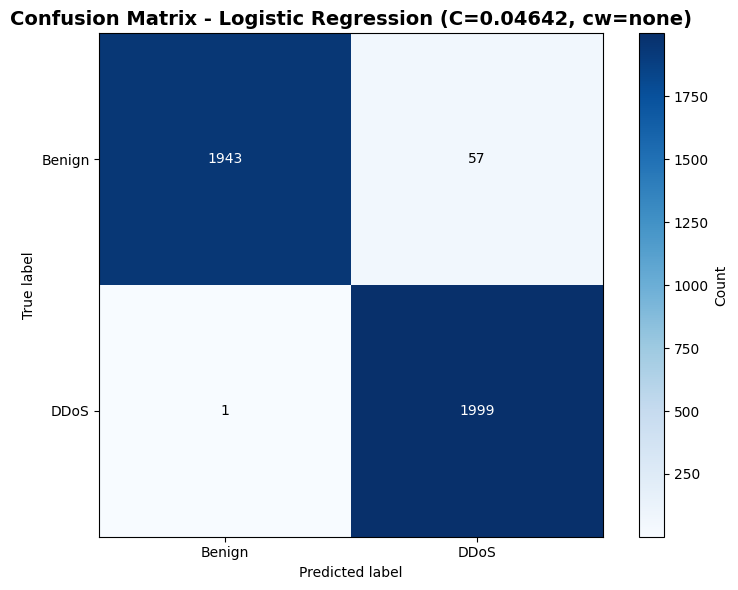

In [16]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Confusion Matrix - Logistic Regression (C={best_C:.4g}, cw={best_cw_name})", fontsize=14, fontweight="bold")
plt.colorbar(label="Count")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.xticks([0, 1], ["Benign", "DDoS"])
plt.yticks([0, 1], ["Benign", "DDoS"])
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("../../plots/lr_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

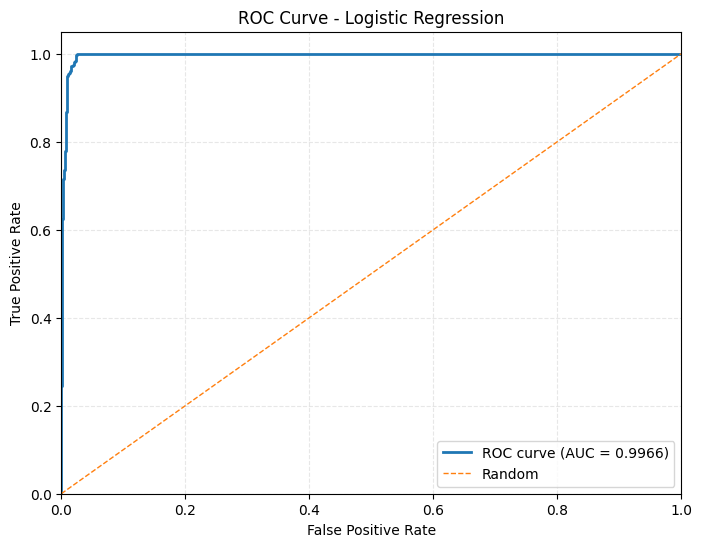

ROC AUC: 0.99663575


In [17]:
y_test_proba = final_lr.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.3)
plt.savefig("../../plots/lr_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("ROC AUC:", roc_auc)

In [18]:
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

cv_scores = cross_val_score(final_lr, X_trainval, y_trainval, cv=5, scoring="accuracy")

print(f"Scores per fold: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Scores per fold: [0.9821875 0.9859375 0.984375  0.9859375 0.9840625]
Mean CV Accuracy: 0.9845 (+/- 0.0014)


In [19]:
print(f"Dataset Size: {len(X)} samples")
print(f"Features: {X.shape[1]}")
print(f"Classes: Benign (0), DDoS (1)")
print(f"\nBest C: {best_C:.4g}")
print(f"Best class_weight: {best_cw_name}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"CV Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Dataset Size: 20000 samples
Features: 79
Classes: Benign (0), DDoS (1)

Best C: 0.04642
Best class_weight: none
Validation Accuracy: 0.9855
Test Accuracy: 0.9855
ROC AUC: 0.9966
CV Mean Accuracy: 0.9845 (+/- 0.0014)


In [20]:
"""
Save plot data to CSV so plots can be reproduced without re-running the model, and so we can compare.
"""

overfit_rows = []
for cw_name, _ in settings:
    subset = [r for r in val_results if r[1] == cw_name]
    for r in subset:
        overfit_rows.append({
            "C": r[0],
            "class_weight": cw_name,
            "train_accuracy": r[2],
            "val_accuracy": r[3],
            "overfit_gap": r[2] - r[3]
        })

pd.DataFrame(overfit_rows).to_csv("../../data/lr_overfit_gap.csv", index=False)

pd.DataFrame(
    cm,
    index=["True_Benign", "True_DDoS"],
    columns=["Pred_Benign", "Pred_DDoS"]
).to_csv("../../data/lr_confusion_matrix.csv")

pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds
}).to_csv("../../data/lr_roc_curve.csv", index=False)

coef_df.sort_values("abs_coefficient", ascending=False).to_csv(
    "../../data/lr_feature_coefficients.csv", index=False
)

print("Saved:")
print("  ../../data/lr_overfit_gap.csv")
print("  ../../data/lr_confusion_matrix.csv")
print("  ../../data/lr_roc_curve.csv")
print("  ../../data/lr_threshold_sweep.csv")
print("  ../../data/lr_feature_coefficients.csv")

Saved:
  ../../data/lr_overfit_gap.csv
  ../../data/lr_confusion_matrix.csv
  ../../data/lr_roc_curve.csv
  ../../data/lr_threshold_sweep.csv
  ../../data/lr_feature_coefficients.csv


In [20]:
"""
Save resource usage:
    Appends RAM usage, CPU time, and wall time (MB, sec) to csv.
"""

end_wall = time.time()
end_mem, end_cpu = get_usage()

usage_df = pd.DataFrame([{
    "model": "LR",
    "ram_delta_mb": end_mem - start_mem,
    "cpu_time_sec": end_cpu - start_cpu,
    "wall_time_sec": end_wall - start_wall
}])

usage_file = "../../data/resource_usage.csv"
usage_df.to_csv(usage_file, mode='a', header=not os.path.exists(usage_file), index=False)

In [ ]:
"""
Save model:
    Saves a pkl file of the trained model.
"""
os.makedirs("../../data/models", exist_ok=True)
joblib.dump(final_lr, "../../data/models/lr_model.pkl")